In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import cv2
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from sklearn.metrics import cohen_kappa_score, confusion_matrix
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [2]:
df = pd.read_csv("./dataset/messidor_data.csv")
df = df.sort_values(by='id_code').reset_index(drop=True)
paired_data = []
for i in range(0, len(df), 2):
    img_1 = df.iloc[i]
    img_2 = df.iloc[i+1]
    patient_diagnosis = max(img_1['diagnosis'], img_2['diagnosis'])
    paired_data.append({
        'left': img_1['id_code'],
        'right': img_2['id_code'],
        'diagnosis': patient_diagnosis
    })
paired_df = pd.DataFrame(paired_data)
paired_df.to_csv("./dataset/modified_messidor.csv", index=False)

print(f"Successfully processed {len(df)} images.")
print(f"Created {len(paired_df)} patient examinations.")
print(f"Saved to modified_messidor.csv")

Successfully processed 1744 images.
Created 872 patient examinations.
Saved to modified_messidor.csv


In [3]:
def ben_graham(img_path, sigmaX=10):
    image = cv2.imread(img_path)
    if image is None:
        raise FileNotFoundError(f"Image was not found at path: {img_path}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    blurred = cv2.GaussianBlur(image, (0, 0), sigmaX)
    processed_img = cv2.addWeighted(image, 4, blurred, -4, 128)
    return Image.fromarray(processed_img)

In [4]:
class MessidorSiameseDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.data_frame = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform
        
    def __len__(self):
        return len(self.data_frame)
    
    def __getitem__(self, index):
        left_img_path = os.path.join(self.root_dir, str(self.data_frame.iloc[index]["left"]))
        right_img_path = os.path.join(self.root_dir, str(self.data_frame.iloc[index]["right"]))
        
        img_left = ben_graham(left_img_path)
        img_right = ben_graham(right_img_path)
        
        label = int(self.data_frame.iloc[index]["diagnosis"])
        
        if self.transform:
            img_left = self.transform(img_left)
            img_right = self.transform(img_right)
            
        return img_left, img_right, torch.tensor(label, dtype=torch.long)

In [5]:
resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = MessidorSiameseDataset(
    csv_file="./dataset/modified_messidor.csv",
    root_dir="./dataset/messidor-2/messidor-2/preprocess/",
    transform=resnet_transform
)

dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

left_batch, right_batch, labels = next(iter(dataloader))
print(f"Loaded a batch of {len(labels)} patients.")
print(f"Diagnoses for this batch: {labels}")

Loaded a batch of 8 patients.
Diagnoses for this batch: tensor([1, 2, 2, 1, 2, 1, 2, 0])


In [6]:
class SiameseResNet50(nn.Module):
    def __init__(self, num_classes=5, dropout_rate=0.4):
        super().__init__()
        self.backbone = models.resnet50(weights="DEFAULT")
        self.feature_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.classifier = nn.Sequential(
            nn.Linear(self.feature_dim * 2, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, left_eye, right_eye):
        left = self.backbone(left_eye)
        right = self.backbone(right_eye)
        combined = torch.cat((left, right), 1)
        output = self.classifier(combined)
        return output

In [7]:
model = SiameseResNet50()
dummy_left_batch = torch.randn(8, 3, 224, 224)
dummy_right_batch = torch.randn(8, 3, 224, 224)

output = model(dummy_left_batch, dummy_right_batch)
# output
print(sum(p.numel() for p in model.parameters()))

25609285


In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [9]:
df = pd.read_csv("./dataset/modified_messidor.csv")
num_classes = 5
weight = []
for i in range(num_classes):
    weight.append(len(df)/(num_classes*len(df[df["diagnosis"] == i])))
weight

[0.4349127182044888,
 1.0832298136645964,
 0.7716814159292036,
 2.9066666666666667,
 7.266666666666667]

In [10]:
def train_siamese_model(model, dataloader, criteria, optimizer, epochs=10):
    for epoch in range(epochs):
        model.train()
        running_loss = 0
        correct_predictions = 0
        total_samples = 0
        for batch_idx, (left, right, labels) in enumerate(dataloader):
            left = left.to(device)
            right = right.to(device)
            labels = labels.to(device)
            model = model.to(device)
            
            optimizer.zero_grad()
            output = model(left, right)
            loss = criteria(output, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * labels.size(0)
            
            _, predicted = torch.max(output, 1)
            correct_predictions += (predicted == labels).sum().item()
            total_samples += labels.size(0)
            
            if (batch_idx + 1) % 10 == 0:
                print(f"Epoch [{epoch+1}/{epochs}] | Batch [{batch_idx+1}/{len(dataloader)}] | Current Loss: {loss.item():.4f}")
        epoch_loss = running_loss/total_samples
        epoch_acc = (correct_predictions/total_samples) * 100
        
        print("-" * 50)
        print(f"End of Epoch {epoch+1} | Total Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")
        print("-" * 50)
        
    print("Training complete")
    return model
        

In [11]:
def evaluate_model(model, dataloader, device):
    model.eval()
    
    all_predictions = []
    all_true_labels = []
    
    print("Evaluating model...")
    with torch.no_grad():
        for left_eye, right_eye, labels in dataloader:
            left_eye = left_eye.to(device)
            right_eye = right_eye.to(device)
            labels = labels.to(device)
            
            outputs = model(left_eye, right_eye)
            _, predicted = torch.max(outputs, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_true_labels.extend(labels.cpu().numpy())
            
    qwk = cohen_kappa_score(all_true_labels, all_predictions, weights='quadratic')
    
    print(f"Final Quadratic Weighted Kappa (QWK): {qwk:.4f}")
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(all_true_labels, all_predictions))
    
    return qwk

In [12]:
class SiameseWrapper(torch.nn.Module):
    def __init__(self, model, fixed_right_eye):
        super().__init__()
        self.model = model
        self.fixed_right_eye = fixed_right_eye

    def forward(self, left_eye):
        return self.model(left_eye, self.fixed_right_eye)

def generate_heatmap(model, left_tensor, right_tensor, original_image_numpy, device, target_class=None):
    """
    left_tensor/right_tensor: [3,224,224] or [1,3,224,224] (normalized tensors)
    original_image_numpy: uint8 RGB image (H, W, 3) used for overlay
    """
    model.eval()

    if left_tensor.dim() == 3:
        left_tensor = left_tensor.unsqueeze(0)
    if right_tensor.dim() == 3:
        right_tensor = right_tensor.unsqueeze(0)

    left_tensor = left_tensor.to(device)
    right_tensor = right_tensor.to(device)
    model = model.to(device)

    wrapper = SiameseWrapper(model, right_tensor)
    target_layers = [wrapper.model.backbone.layer4[-1]]

    with GradCAM(model=wrapper, target_layers=target_layers) as cam:
        grayscale_cam = cam(input_tensor=left_tensor, targets=target_class)[0]

    original = original_image_numpy.astype(np.float32) / 255.0

    if grayscale_cam.shape[:2] != original.shape[:2]:
        grayscale_cam = cv2.resize(grayscale_cam, (original.shape[1], original.shape[0]))

    visualization = show_cam_on_image(original, grayscale_cam, use_rgb=True)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original Left Eye")
    plt.imshow(original_image_numpy)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("Grad-CAM: AI Focus Area")
    plt.imshow(visualization)
    plt.axis("off")
    plt.show()

    return visualization

Epoch [1/10] | Batch [10/88] | Current Loss: 1.6225
Epoch [1/10] | Batch [20/88] | Current Loss: 1.4245
Epoch [1/10] | Batch [30/88] | Current Loss: 1.7972
Epoch [1/10] | Batch [40/88] | Current Loss: 1.4563
Epoch [1/10] | Batch [50/88] | Current Loss: 1.3152
Epoch [1/10] | Batch [60/88] | Current Loss: 1.2832
Epoch [1/10] | Batch [70/88] | Current Loss: 1.6045
Epoch [1/10] | Batch [80/88] | Current Loss: 1.2469
--------------------------------------------------
End of Epoch 1 | Total Loss: 1.5106 | Accuracy: 36.68%
--------------------------------------------------
Epoch [2/10] | Batch [10/88] | Current Loss: 1.3438
Epoch [2/10] | Batch [20/88] | Current Loss: 0.5321
Epoch [2/10] | Batch [30/88] | Current Loss: 0.9317
Epoch [2/10] | Batch [40/88] | Current Loss: 0.9637
Epoch [2/10] | Batch [50/88] | Current Loss: 0.4587
Epoch [2/10] | Batch [60/88] | Current Loss: 1.4867
Epoch [2/10] | Batch [70/88] | Current Loss: 1.0846
Epoch [2/10] | Batch [80/88] | Current Loss: 0.6689
-----------

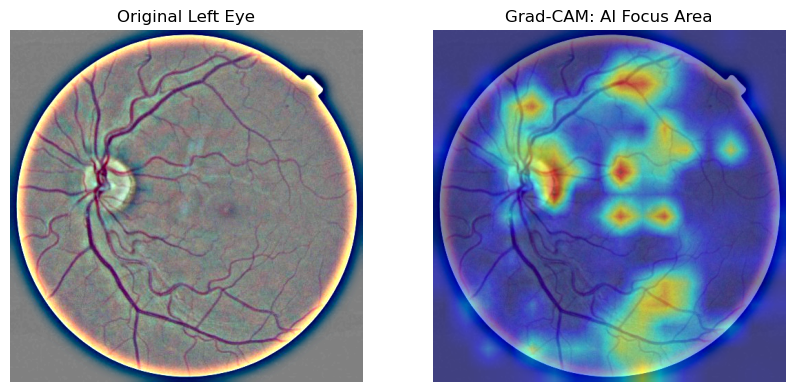

In [13]:
def main():
    model = SiameseResNet50()
    df = pd.read_csv("./dataset/modified_messidor.csv")
    num_classes = 5
    weight = []
    for i in range(num_classes):
        weight.append(len(df)/(num_classes*len(df[df["diagnosis"] == i])))
    weights = torch.tensor(weight, dtype=torch.float32).to(device)
    criteria = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)
    resnet_transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    dataset = MessidorSiameseDataset(
        csv_file="./dataset/modified_messidor.csv",
        root_dir="./dataset/messidor-2/messidor-2/preprocess/",
        transform=resnet_transform
    )
    # dataloader = DataLoader(dataset, batch_size=8, shuffle=True)
    
    test_ratio = 0.2
    test_size = int(len(dataset) * test_ratio)
    train_size = len(dataset) - test_size
    generator = torch.Generator().manual_seed(42)
    train_dataset, test_dataset = random_split(dataset, [train_size, test_size], generator=generator)
    
    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)
    
    trained_model = train_siamese_model(
        model=model,
        dataloader=train_loader,
        criteria=criteria,
        optimizer=optimizer,
        epochs=10
    )
    
    evaluate_model(trained_model, test_loader, device)
    for _, (left, right, label) in enumerate(train_loader):
        left_0 = left[0]
        right_0 = right[0]

        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img = (left_0.cpu() * std + mean).clamp(0, 1)
        original_image_numpy = (img.permute(1, 2, 0).numpy() * 255).astype(np.uint8)

        generate_heatmap(trained_model, left_0, right_0, original_image_numpy, device)
        break
    torch.save(trained_model.state_dict(), "trained_siamese_model.pth")
    
if __name__ == "__main__":
    main()